# Concept Bottleneck on CUB

This notebook stays thin on purpose: the dataset parsing, feature extraction, CBM training, and plotting live in `xai_book.concept_bottleneck`.

Use `CONFIG["variants"]` to compare multiple bottleneck setups without adding notebook-side training code:
- `oracle_concepts`: class model trained on ground-truth concepts
- `sequential_cbm`: concept predictors fit first, then a label model on predicted concepts
- `joint_cbm`: concept and label heads trained together on fixed image features
- `feature_baseline`: baseline label model on the same fixed image features

Expected local layout:

```text
data/cub/raw/CUB_200_2011/
out/
```

If your CUB dataset already lives somewhere else, set `CONFIG["raw_dir"]` to that absolute path instead of moving files around. By default the notebook will also try to download the official archive automatically if the dataset is missing.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = Path("data")
NOTEBOOK_SLUG = "concept_bottleneck"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename: str) -> Path:
    return OUT_DIR / filename

def save_table(frame, filename: str) -> Path:
    path = out_path(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    print(f"saved: {path}")
    return path


In [2]:
from IPython.display import Markdown, display
import pandas as pd

from xai_book.concept_bottleneck import (
    CBM_VARIANT_LABELS,
    CBM_FIGURE_FILENAMES,
    CBM_TABLE_FILENAMES,
    SUPPORTED_CBM_VARIANTS,
    build_cub_concept_bottleneck_demo,
    cub_data_paths,
    cub_dataset_available,
    cub_raw_dir_candidates,
)
from xai_book.plotting import display_and_save_figure

CONFIG = {
    "raw_dir": None,
    "download_if_missing": True,
    "download_url": None,
    "variants": list(SUPPORTED_CBM_VARIANTS),
    "primary_variant": "joint_cbm",
    "n_classes": 20,
    "n_concepts": 12,
    "batch_size": 32,
    "random_state": 7,
    "device": None,
    "joint_epochs": 200,
    "joint_learning_rate": 5e-3,
    "joint_weight_decay": 1e-4,
    "joint_batch_size": 256,
    "concept_loss_weight": 1.0,
}

paths = cub_data_paths(DATA_DIR, raw_dir=CONFIG["raw_dir"])
dataset_found = cub_dataset_available(paths)
enabled_variants = ", ".join(CBM_VARIANT_LABELS[variant] for variant in CONFIG["variants"])

display(
    pd.Series(
        {
            "resolved_raw_dir": str(paths.raw_dir),
            "cache_dir": str(paths.cache_dir),
            "dataset_found": dataset_found,
            "enabled_variants": enabled_variants,
            "primary_variant": CBM_VARIANT_LABELS[CONFIG["primary_variant"]],
            "download_if_missing": CONFIG["download_if_missing"],
        },
        name="setup",
    ).to_frame()
)

if not dataset_found:
    searched = "\n".join(f"- `{path}`" for path in cub_raw_dir_candidates(DATA_DIR, raw_dir=CONFIG["raw_dir"]))
    display(
        Markdown(
            "Raw CUB data not found.\\n\\n"
            "The next cell will download the official archive automatically if `CONFIG[\"download_if_missing\"]` is `True`. You can also set `CONFIG[\"raw_dir\"]` to an existing absolute path.\\n\\n"
            "Searched locations:\\n"
            f"{searched}"
        )
    )


,setup
resolved_raw_dir,data/cub/raw/CUB_200_2011
cache_dir,data/cub/cache
dataset_found,True
enabled_variants,"Oracle concepts, Sequential CBM, Joint CBM, Fe..."
primary_variant,Joint CBM
download_if_missing,True


,summary
backbone,IMAGENET1K_V1
selected_classes,20
selected_concepts,12
enabled_variants,"Oracle concepts, Sequential CBM, Joint CBM, Fe..."
primary_variant,Joint CBM
train_images,599
test_images,573


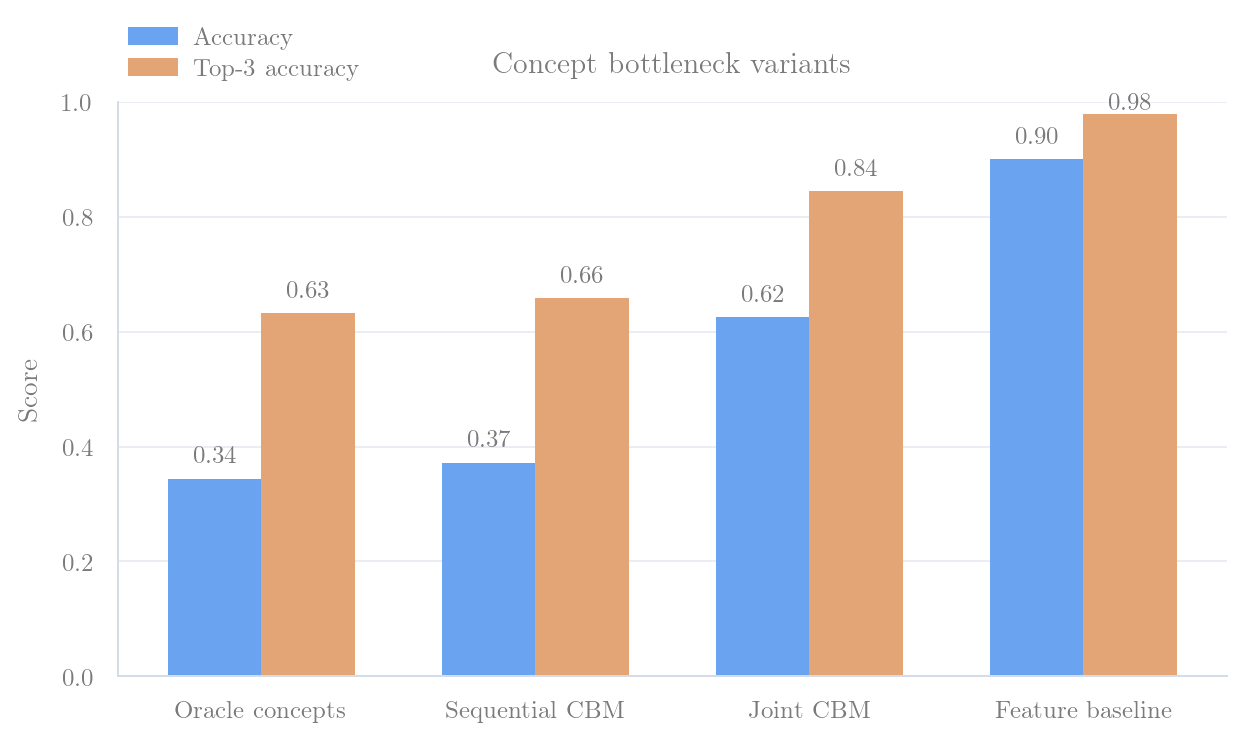

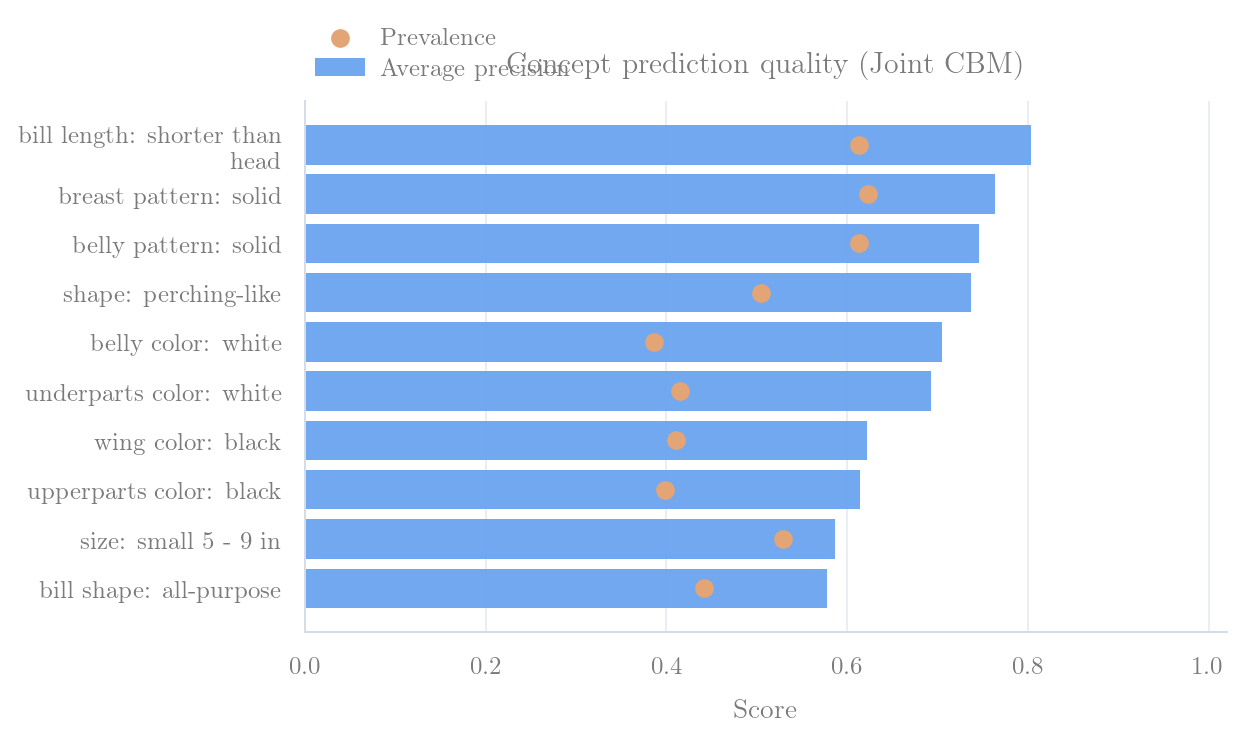

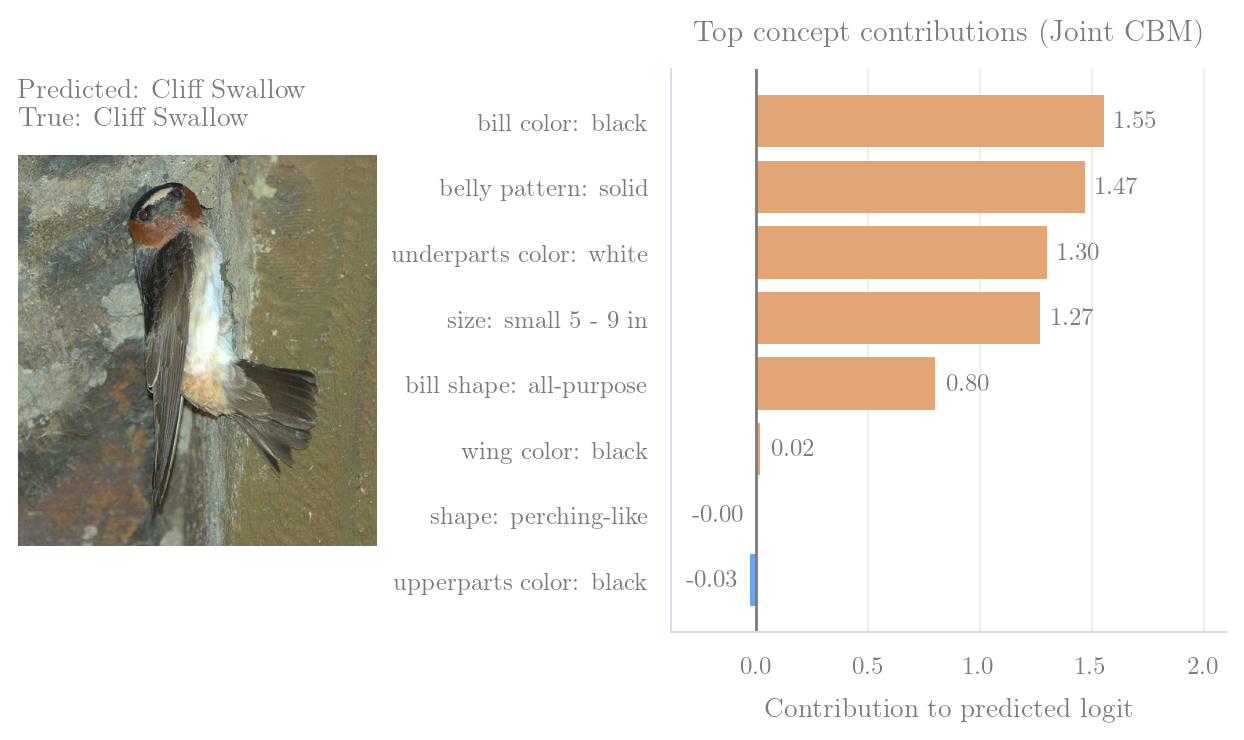

In [3]:
results = None

if dataset_found or CONFIG["download_if_missing"]:
    results = build_cub_concept_bottleneck_demo(
        data_dir=DATA_DIR,
        raw_dir=CONFIG["raw_dir"],
        download_if_missing=CONFIG["download_if_missing"],
        download_url=CONFIG["download_url"],
        variants=CONFIG["variants"],
        primary_variant=CONFIG["primary_variant"],
        n_classes=CONFIG["n_classes"],
        n_concepts=CONFIG["n_concepts"],
        batch_size=CONFIG["batch_size"],
        random_state=CONFIG["random_state"],
        device=CONFIG["device"],
        joint_epochs=CONFIG["joint_epochs"],
        joint_learning_rate=CONFIG["joint_learning_rate"],
        joint_weight_decay=CONFIG["joint_weight_decay"],
        joint_batch_size=CONFIG["joint_batch_size"],
        concept_loss_weight=CONFIG["concept_loss_weight"],
    )

    summary = pd.Series(
        {
            "backbone": results["summary"]["backbone"],
            "selected_classes": results["summary"]["selected_classes"],
            "selected_concepts": results["summary"]["selected_concepts"],
            "enabled_variants": ", ".join(results["summary"]["variant_labels"]),
            "primary_variant": results["summary"]["primary_variant_label"],
            "train_images": results["summary"]["train_images"],
            "test_images": results["summary"]["test_images"],
        },
        name="summary",
    )
    display(summary.to_frame())
else:
    display(Markdown("Dataset unavailable, so the CBM fit step is skipped."))


In [4]:
if results is None:
    print("No tables saved because the raw CUB dataset is not available yet.")
else:
    for name, frame in results["tables"].items():
        save_table(frame, f"{CBM_TABLE_FILENAMES[name]}.csv")

    display(results["tables"]["model_metrics"])

    primary_variant = results["summary"]["primary_variant"]
    concept_preview = results["tables"]["concept_metrics"].loc[
        lambda frame: frame["variant"] == primary_variant,
        ["concept", "test_prevalence", "balanced_accuracy", "average_precision"],
    ].head(10)
    explanation_preview = results["tables"]["explanation"][
        ["concept", "contribution", "predicted_probability", "ground_truth"]
    ].head(8)

    display(concept_preview)
    display(explanation_preview)


saved: out/concept_bottleneck/concept_bottleneck_model_metrics.csv
saved: out/concept_bottleneck/concept_bottleneck_concept_metrics.csv
saved: out/concept_bottleneck/concept_bottleneck_explanation.csv


,variant,model,accuracy,top_3_accuracy
0,oracle_concepts,Oracle concepts,0.343805,0.631763
1,sequential_cbm,Sequential CBM,0.371728,0.657941
2,joint_cbm,Joint CBM,0.624782,0.844677
3,feature_baseline,Feature baseline,0.900524,0.979058


,concept,test_prevalence,balanced_accuracy,average_precision
0,bill length: shorter than head,0.612565,0.701913,0.802868
1,breast pattern: solid,0.623037,0.631458,0.763122
2,belly pattern: solid,0.612565,0.637657,0.745863
3,shape: perching-like,0.504363,0.701380,0.737041
4,belly color: white,0.385689,0.720575,0.704743
5,underparts color: white,0.415358,0.688430,0.692233
6,wing color: black,0.410122,0.647268,0.621360
7,upperparts color: black,0.397906,0.648894,0.614056
8,size: small 5 - 9 in,0.528796,0.558177,0.586681
9,bill shape: all-purpose,0.441536,0.610598,0.577396


,concept,contribution,predicted_probability,ground_truth
0,bill color: black,1.552474,0.994890,1
1,belly pattern: solid,1.469526,0.991223,1
2,underparts color: white,1.300259,0.992898,1
3,size: small 5 - 9 in,1.269865,0.909437,0
4,bill shape: all-purpose,0.798370,0.932194,0
5,wing color: black,0.018137,0.054298,0
6,shape: perching-like,-0.000368,0.000200,0
7,upperparts color: black,-0.025679,0.012279,0


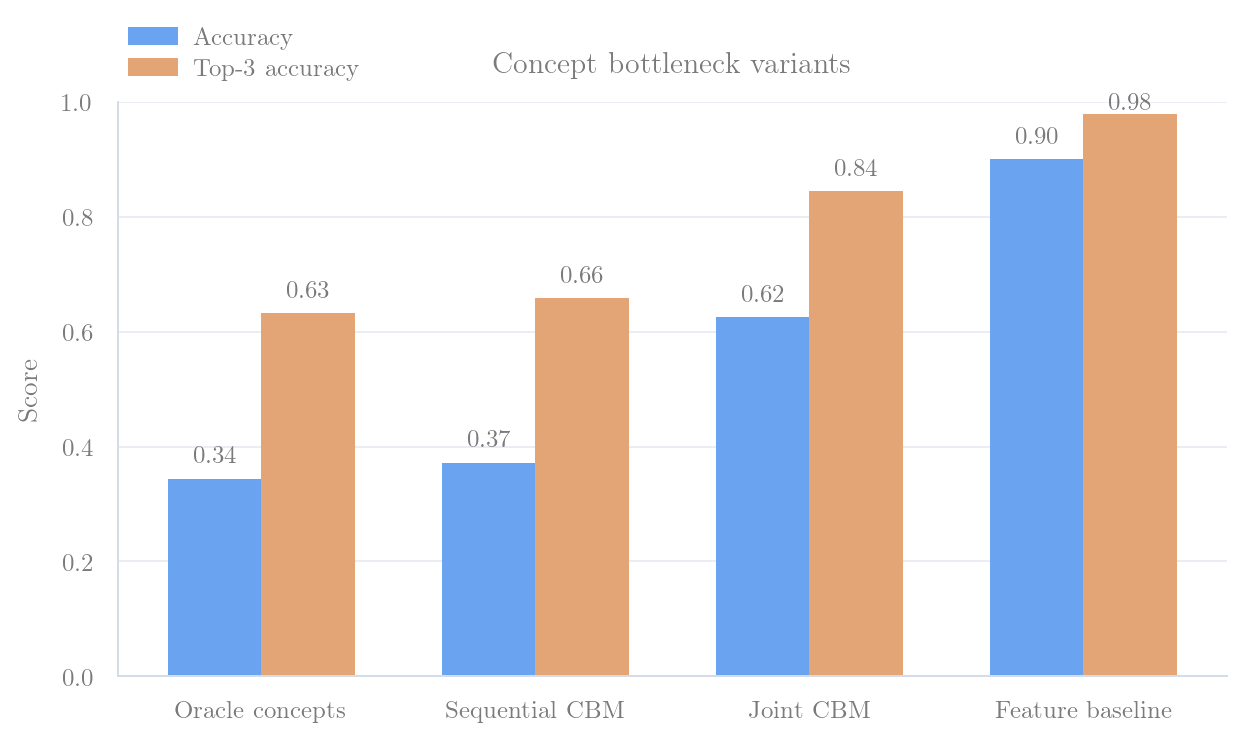

saved: out/concept_bottleneck/concept_bottleneck_model_comparison.pdf


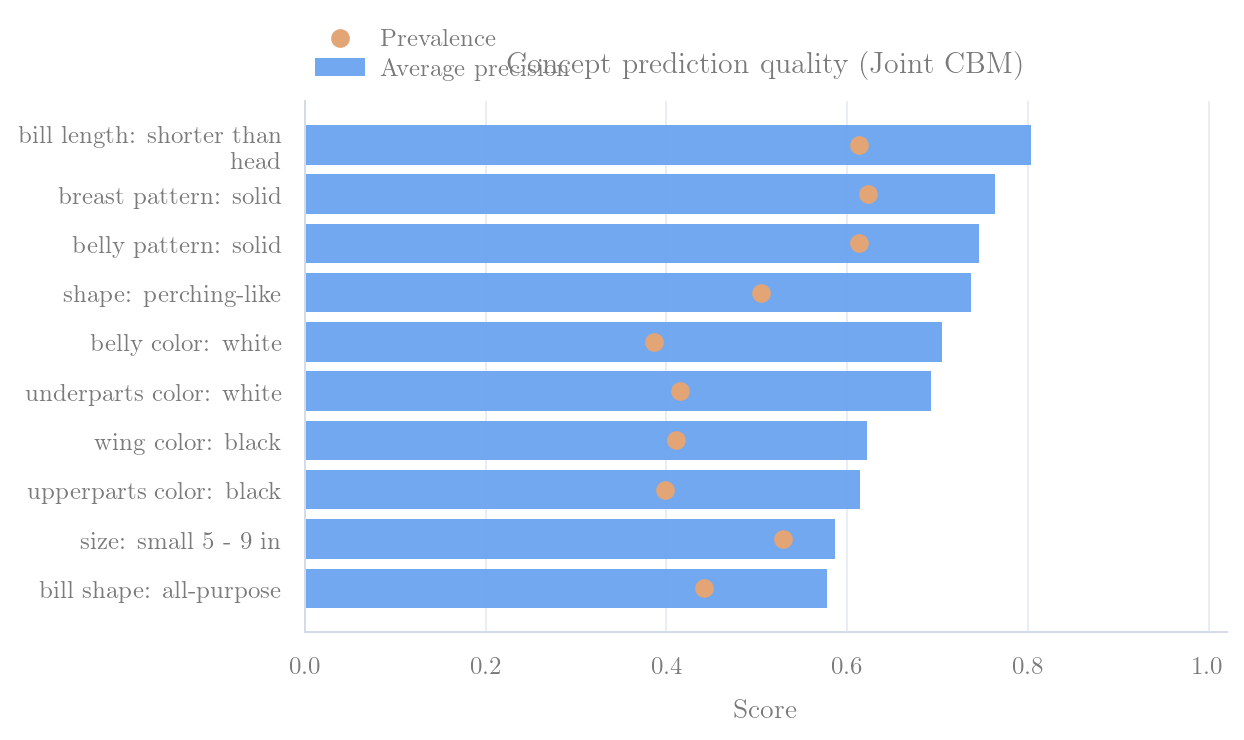

saved: out/concept_bottleneck/concept_bottleneck_concept_quality.pdf


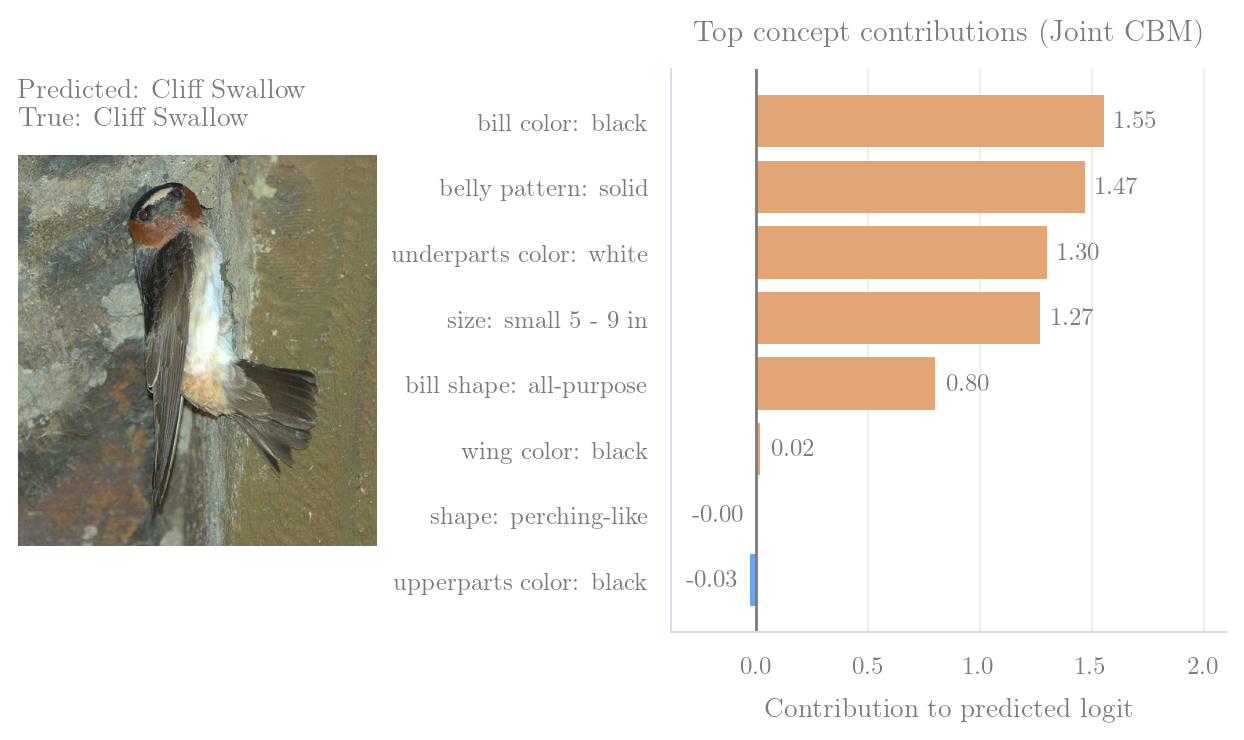

saved: out/concept_bottleneck/concept_bottleneck_prediction_explanation.pdf


In [5]:
if results is None:
    print("No figures saved because the raw CUB dataset is not available yet.")
else:
    for name, fig in results["figures"].items():
        path = display_and_save_figure(fig, out_path(f"{CBM_FIGURE_FILENAMES[name]}.pdf"))
        print(f"saved: {path}")
